ПЕРВЫЕ 5 СТРОК ДАТАСЕТА ДИАБЕТА
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

ИНФОРМАЦИЯ О ДАТАСЕТЕ:
Размер: (768, 9) строк, 9 колонок
Колонки: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Уникальные значения целевой переменной (Outcome): [0, 1]

ОБЩИЕ ПАРАМЕТРЫ ДЛЯ В

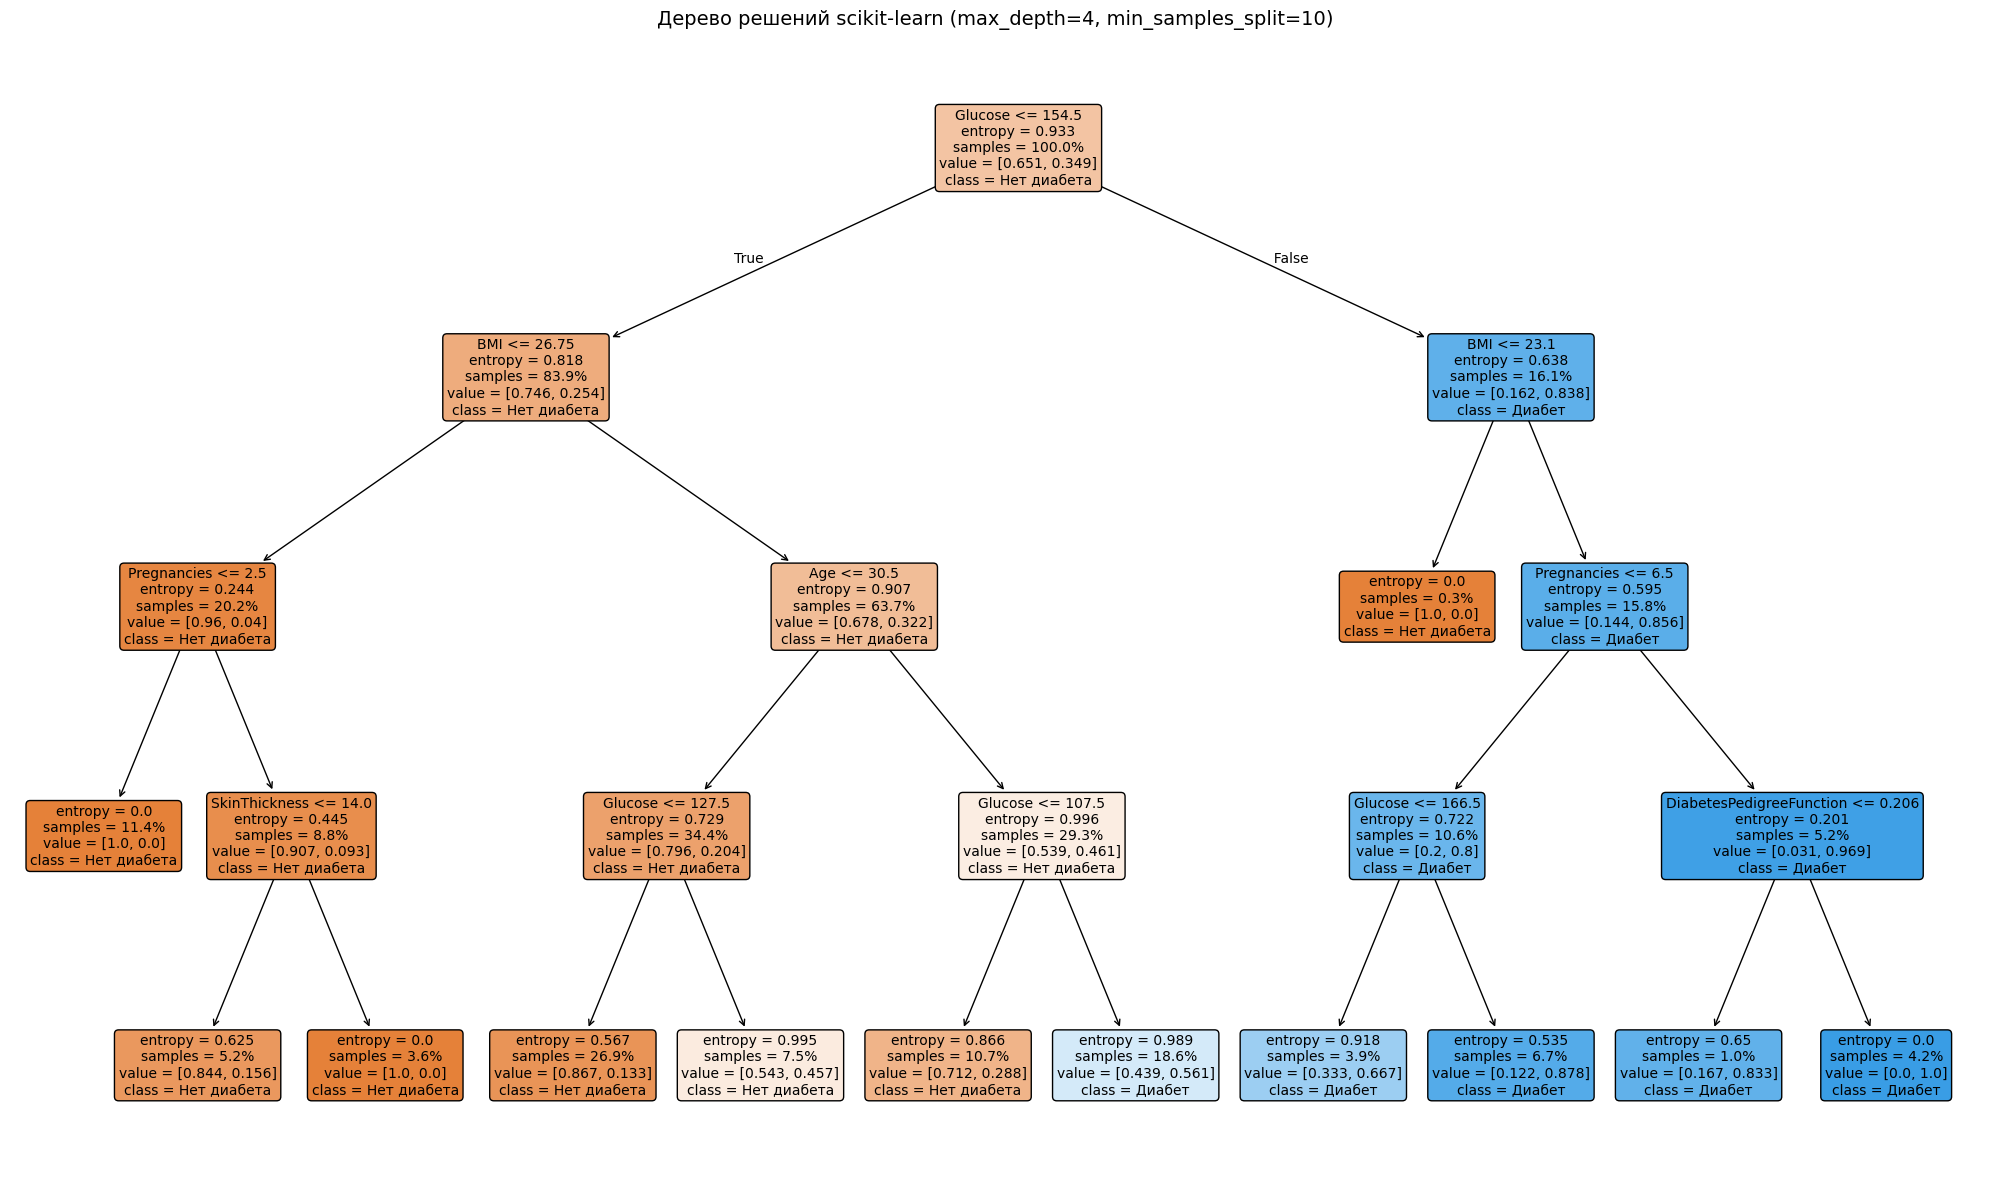


АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

Важность признаков (scikit-learn), отсортированная по убыванию:
                 Признак  Важность
                 Glucose  0.588373
                     BMI  0.214432
                     Age  0.109540
             Pregnancies  0.054211
           SkinThickness  0.020568
DiabetesPedigreeFunction  0.012876
           BloodPressure  0.000000
                 Insulin  0.000000

ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МОДЕЛЕЙ


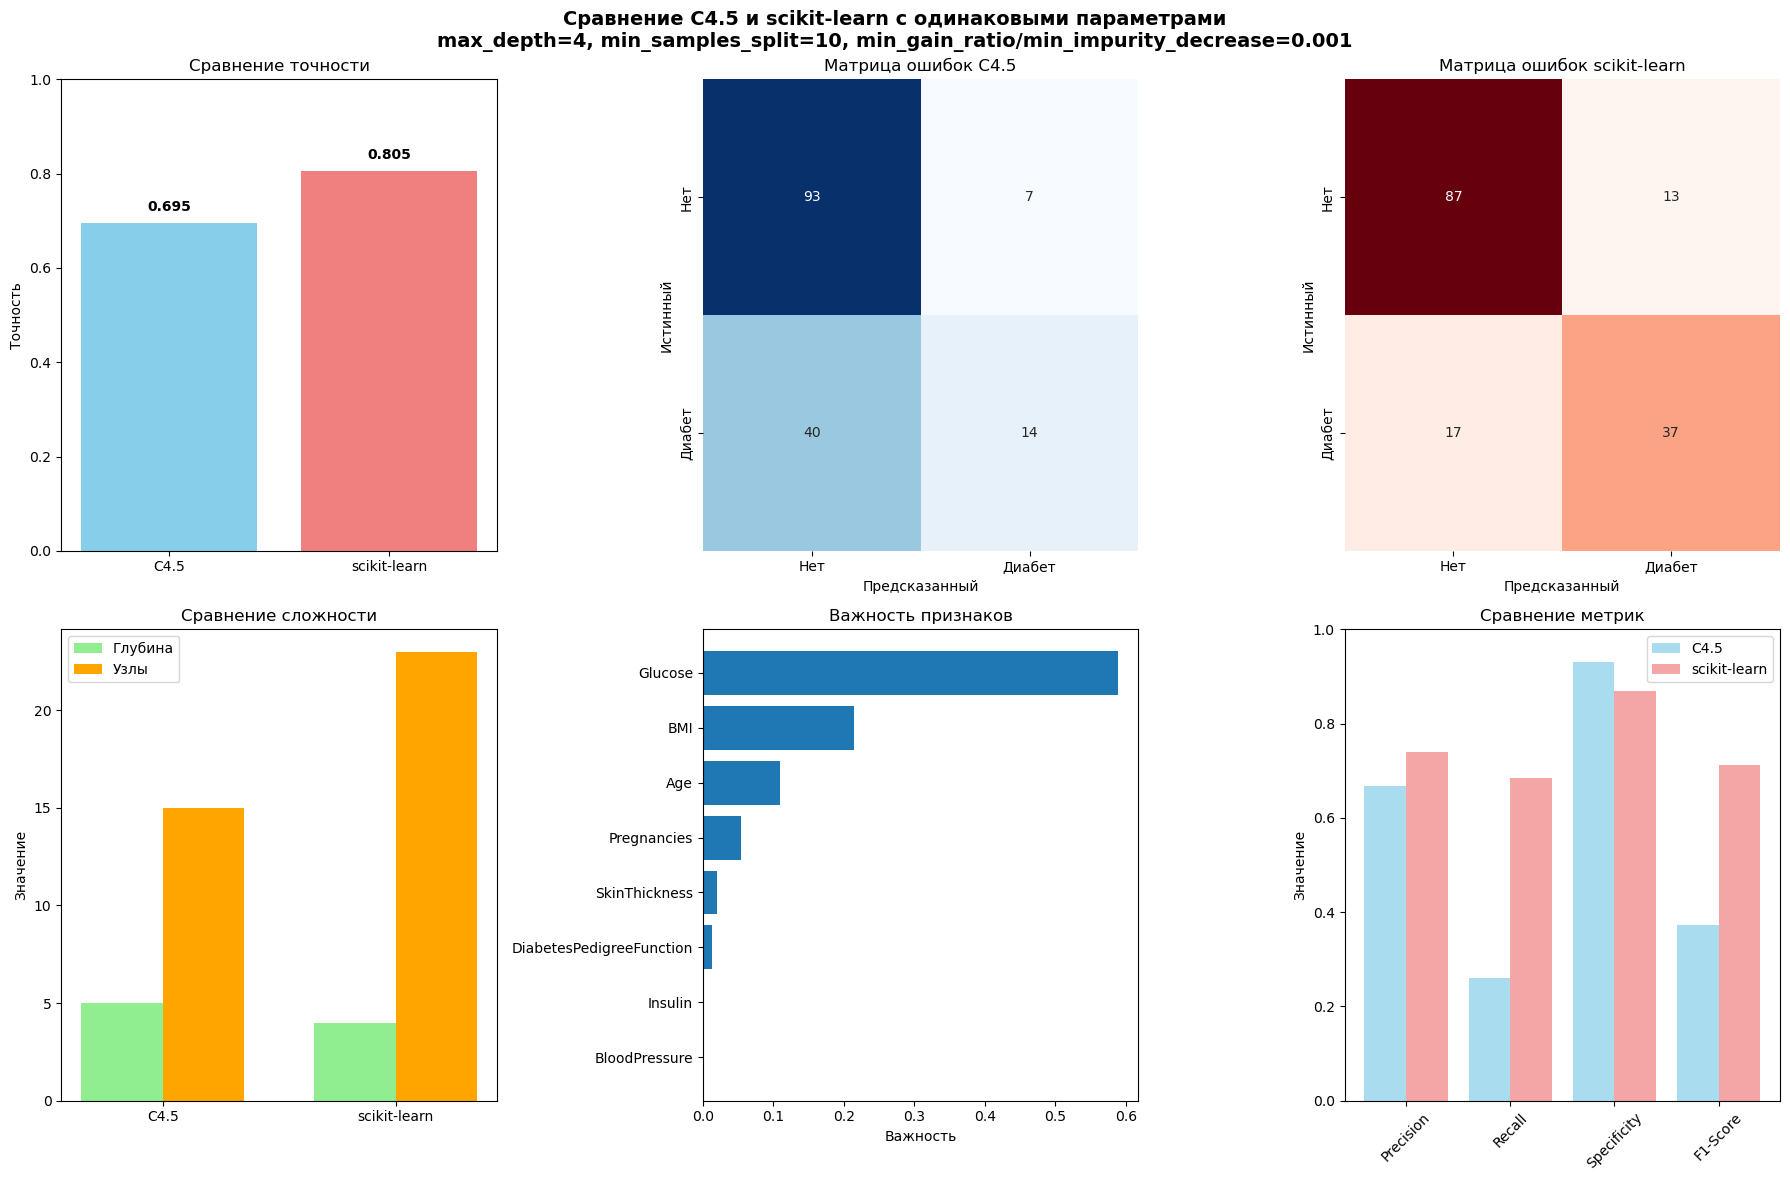


АНАЛИЗ РАСПРЕДЕЛЕНИЯ ВАЖНЫХ ПРИЗНАКОВ


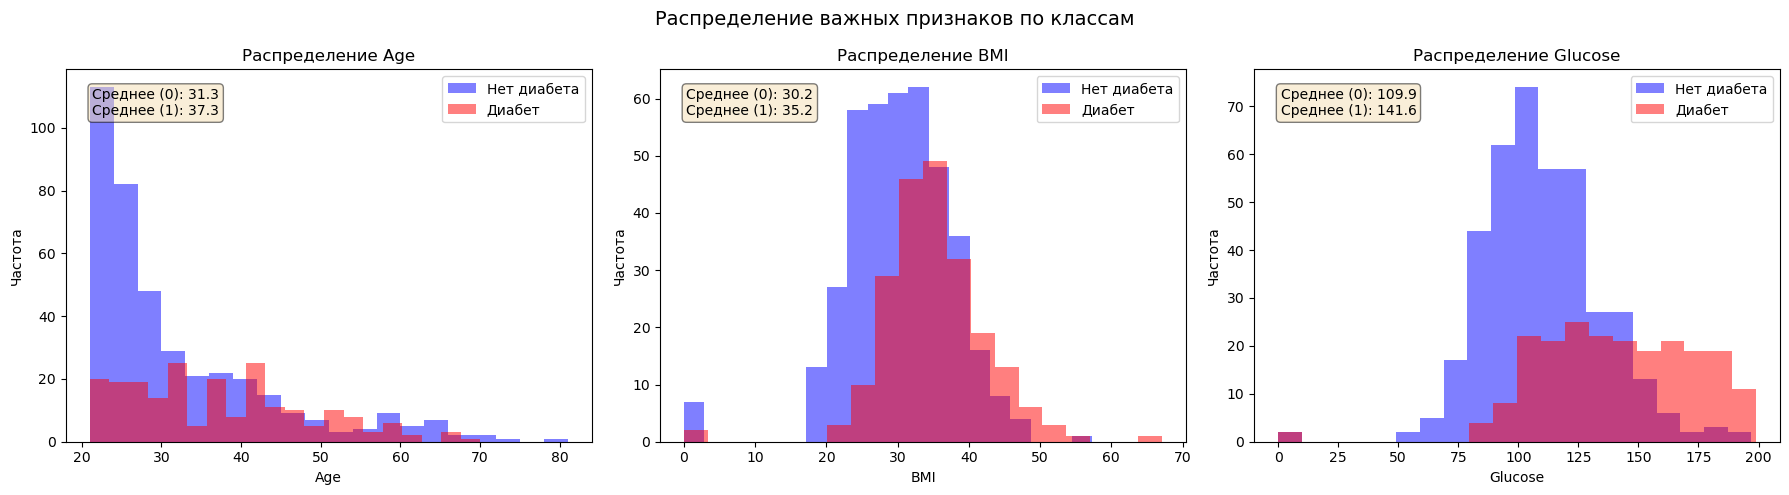


СТРУКТУРА ДЕРЕВА C4.5

Текстовое представление дерева C4.5:
Glucose <= 158.5000 [GR: 0.2279]
    L: BMI <= 62.2000 [GR: 0.1809]
        L: DiabetesPedigreeFunction <= 2.0345 [GR: 0.1817]
            L: BMI <= 47.5500 [GR: 0.1610]
                L: Класс: 0
            L: BMI > 47.5500
                R: Класс: 1
        L: DiabetesPedigreeFunction > 2.0345
            R: Класс: 1
    L: BMI > 62.2000
        R: Класс: 1
Glucose > 158.5000
    R: BMI <= 23.1000 [GR: 0.4453]
        L: Класс: 0
    R: BMI > 23.1000
        R: Insulin <= 661.5000 [GR: 0.4160]
            L: BloodPressure <= 108.0000 [GR: 0.1134]
                L: Класс: 1
            L: BloodPressure > 108.0000
                R: Класс: 1
        R: Insulin > 661.5000
            R: Класс: 0

ИТОГОВЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ

1. ТОЧНОСТЬ МОДЕЛЕЙ:
   • C4.5 (ручная реализация): 0.6948
   • scikit-learn: 0.8052
   • Разница: 0.1104 (15.9%)

2. СЛОЖНОСТЬ МОДЕЛЕЙ:
   • C4.5: 15 узлов, глубина 5
   • scikit-learn: 23 узлов, глуб

In [3]:
# ============================================
# ОБЩИЕ ПАРАМЕТРЫ ДЛЯ ВСЕХ МОДЕЛЕЙ
# ============================================

# Параметры для контроля переобучения и сложности моделей
MAX_DEPTH = 4                     # Максимальная глубина дерева (ограничивает сложность)
MIN_SAMPLES_SPLIT = 10            # Минимальное количество образцов для разбиения узла
MIN_GAIN_RATIO = 0.001            # Минимальный Gain Ratio для C4.5 (аналог min_impurity_decrease)
MIN_IMPURITY_DECREASE = 0.001     # Минимальное уменьшение неопределенности для scikit-learn
RANDOM_STATE = 42                 # Для воспроизводимости результатов

# ============================================
# ИМПОРТ БИБЛИОТЕК
# ============================================

import pandas as pd               # Для работы с табличными данными
import numpy as np                # Для математических операций и работы с массивами
import matplotlib.pyplot as plt   # Для создания графиков и визуализаций
from sklearn.model_selection import train_test_split  # Для разделения данных
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Метрики оценки
from sklearn.tree import DecisionTreeClassifier, plot_tree  # Библиотечная реализация дерева
import seaborn as sns             # Для дополнительной визуализации
import math                       # Для математических функций (log2)

# ============================================
# ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ
# ============================================

# Загрузка датасета диабета из CSV файла
df = pd.read_csv('diabetes.csv')

# Вывод первых 5 строк датасета для ознакомления
print("=" * 70)
print("ПЕРВЫЕ 5 СТРОК ДАТАСЕТА ДИАБЕТА")
print("=" * 70)
print(df.head())

# Вывод основной информации о датасете
print(f"\nИНФОРМАЦИЯ О ДАТАСЕТЕ:")
print(f"Размер: {df.shape} строк, {df.shape[1]} колонок")
print(f"Колонки: {df.columns.tolist()}")
print(f"Уникальные значения целевой переменной (Outcome): {sorted(df['Outcome'].unique())}")

# ============================================
# ВЫВОД ИНФОРМАЦИИ ОБ ОБЩИХ ПАРАМЕТРАХ
# ============================================

print("\n" + "=" * 70)
print("ОБЩИЕ ПАРАМЕТРЫ ДЛЯ ВСЕХ МОДЕЛЕЙ")
print("=" * 70)
print(f"MAX_DEPTH = {MAX_DEPTH}")
print("  • Максимальная глубина дерева")
print("  • Влияние: ограничивает сложность модели, предотвращает переобучение")
print("  • Меньше значение → проще модель, меньше переобучение")
print("  • Больше значение → сложнее модель, лучше обучение, риск переобучения\n")

print(f"MIN_SAMPLES_SPLIT = {MIN_SAMPLES_SPLIT}")
print("  • Минимальное количество образцов для разбиения узла")
print("  • Влияние: предотвращает разбиение мелких узлов")
print("  • Больше значение → меньше разбиений, проще дерево")
print("  • Меньше значение → больше разбиений, сложнее дерево\n")

print(f"MIN_GAIN_RATIO = {MIN_GAIN_RATIO} (для C4.5)")
print(f"MIN_IMPURITY_DECREASE = {MIN_IMPURITY_DECREASE} (для scikit-learn)")
print("  • Минимальное улучшение качества для создания разбиения")
print("  • Влияние: фильтрует слабые, незначимые разбиения")
print("  • Больше значение → только сильные разбиения, проще дерево")
print("  • Меньше значение → больше разбиений, сложнее дерево\n")

print(f"RANDOM_STATE = {RANDOM_STATE}")
print("  • Инициализация генератора случайных чисел")
print("  • Влияние: обеспечивает воспроизводимость результатов")
print("  • Одинаковое значение → одинаковые результаты при каждом запуске")

# ============================================
# ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ
# ============================================

# Выбор признаков (все колонки кроме 'Outcome') и целевой переменной
features = [col for col in df.columns if col != 'Outcome']  # Список признаков
X = df[features].values   # Преобразование признаков в numpy массив
y = df['Outcome'].values  # Преобразование целевой переменной в numpy массив

# Вывод информации о признаках и распределении классов
print(f"\nПРИЗНАКИ ДЛЯ ОБУЧЕНИЯ ({len(features)} шт): {features}")
print(f"РАСПРЕДЕЛЕНИЕ КЛАССОВ В ДАТАСЕТЕ:")
print(f"  • Класс 0 (нет диабета): {np.sum(y == 0)} образцов ({np.mean(y == 0)*100:.1f}%)")
print(f"  • Класс 1 (диабет): {np.sum(y == 1)} образцов ({np.mean(y == 1)*100:.1f}%)")

# Разделение данных на обучающую (80%) и тестовую (20%) выборки
# stratify=y сохраняет распределение классов в обеих выборках
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

# Вывод информации о размерах выборок
print(f"\nРАЗМЕРЫ ВЫБОРОК ПОСЛЕ РАЗДЕЛЕНИЯ:")
print(f"Обучающая выборка: {X_train.shape} ({X_train.shape[0]} образцов, {X_train.shape[1]} признаков)")
print(f"Тестовая выборка: {X_test.shape} ({X_test.shape[0]} образцов, {X_test.shape[1]} признаков)")

# Разделение обучающей выборки по классам для анализа
x1_train = X_train[y_train == 1]  # Образцы с диабетом
x0_train = X_train[y_train == 0]  # Образцы без диабета

print(f"\nРАСПРЕДЕЛЕНИЕ КЛАССОВ В ОБУЧАЮЩЕЙ ВЫБОРКЕ:")
print(f"  • Образцов с диабетом: {len(x1_train)}")
print(f"  • Образцов без диабета: {len(x0_train)}")

# ============================================
# КЛАСС УЗЛА ДЕРЕВА C4.5
# ============================================

class NodeC45:
    """
    Класс, представляющий узел дерева решений C4.5.
    Узел может быть внутренним (решающим) или листовым (конечным).
    """
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, 
                 value=None, is_leaf=False, split_info=0, gain_ratio=0, samples=None):
        # Индекс признака для разбиения (только для внутренних узлов)
        self.feature_index = feature_index
        # Пороговое значение для разбиения (для непрерывных признаков)
        self.threshold = threshold
        # Левый потомок (значения признака <= порога)
        self.left = left
        # Правый потомок (значения признака > порога)
        self.right = right
        # Значение класса для листового узла
        self.value = value
        # Флаг, указывающий, является ли узел листовым
        self.is_leaf = is_leaf
        # Информация разбиения (Split Info) - мера равномерности разбиения
        self.split_info = split_info
        # Коэффициент усиления (Gain Ratio) - критерий выбора разбиения в C4.5
        self.gain_ratio = gain_ratio
        # Количество образцов в узле (для статистики)
        self.samples = samples

# ============================================
# КЛАСС ДЕРЕВА РЕШЕНИЙ C4.5 (РУЧНАЯ РЕАЛИЗАЦИЯ)
# ============================================

class C45DecisionTree:
    """
    Ручная реализация алгоритма дерева решений C4.5.
    Особенности C4.5:
    1. Использует энтропию как меру неопределенности
    2. Использует Gain Ratio вместо Information Gain
    3. Обрабатывает непрерывные признаки
    4. Использует предварительную обрезку (pre-pruning)
    """
    def __init__(self, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES_SPLIT, 
                 min_gain_ratio=MIN_GAIN_RATIO):
        # Максимальная глубина дерева (из общих параметров)
        self.max_depth = max_depth
        # Минимальное количество образцов для разбиения (из общих параметров)
        self.min_samples_split = min_samples_split
        # Минимальный коэффициент усиления (из общих параметров)
        self.min_gain_ratio = min_gain_ratio
        # Корень дерева (будет установлен при обучении)
        self.root = None
        # Названия признаков (для интерпретируемости)
        self.feature_names = None
    
    # --------------------------------------------------
    # МЕТОДЫ ВЫЧИСЛЕНИЯ МЕТРИК КАЧЕСТВА РАЗБИЕНИЯ
    # --------------------------------------------------
    
    def calculate_entropy(self, y):
        """
        Вычисление энтропии Шеннона.
        
        Энтропия H = -Σ p_i * log2(p_i)
        где p_i - вероятность i-го класса
        
        Энтропия измеряет неопределенность:
        • 0 - все элементы одного класса (чистый узел)
        • 1 - максимальная неопределенность (равномерное распределение)
        """
        if len(y) == 0:  # Если массив пустой
            return 0
        
        # Подсчет количества элементов каждого класса
        _, counts = np.unique(y, return_counts=True)
        # Вычисление вероятностей каждого класса
        probabilities = counts / len(y)
        # Вычисление энтропии (добавляем маленькое число для избежания log2(0))
        entropy = -np.sum(probabilities * np.log2(probabilities + 1e-10))
        return entropy
    
    def calculate_split_info(self, splits):
        """
        Вычисление информации разбиения (Split Info).
        
        Split Info = -Σ (|D_i|/|D|) * log2(|D_i|/|D|)
        где |D_i| - количество элементов в i-м подмножестве
        |D| - общее количество элементов
        
        Split Info штрафует признаки с большим количеством значений,
        предотвращая выбор таких признаков, как 'ID' или 'дата'.
        """
        # Общее количество элементов во всех подмножествах
        total = sum(len(split) for split in splits)
        if total == 0:  # Если общее количество равно 0
            return 0
        
        split_info = 0
        # Для каждого подмножества вычисляем вклад в split info
        for split in splits:
            if len(split) > 0:  # Если подмножество не пустое
                # Доля элементов в этом подмножестве
                ratio = len(split) / total
                # Добавляем вклад этого подмножества (избегаем log2(0))
                split_info -= ratio * np.log2(ratio + 1e-10)
        return split_info
    
    # --------------------------------------------------
    # ПОИСК ОПТИМАЛЬНЫХ РАЗБИЕНИЙ
    # --------------------------------------------------
    
    def find_best_threshold(self, feature_values, y):
        """
        Поиск лучшего порога для непрерывного признака.
        
        Алгоритм:
        1. Сортируем уникальные значения признака
        2. Проверяем пороги как середины между соседними значениями
        3. Для каждого порога вычисляем Gain Ratio
        4. Выбираем порог с максимальным Gain Ratio
        """
        best_gain_ratio = -1  # Инициализация для поиска максимума
        best_threshold = None
        best_left_indices = None
        best_right_indices = None
        best_split_info = 0
        
        # Получение уникальных значений признака
        sorted_values = np.unique(feature_values)
        if len(sorted_values) <= 1:  # Если только одно уникальное значение
            return best_gain_ratio, best_threshold, best_left_indices, best_right_indices, best_split_info
        
        # Проверяем возможные пороги (середины между соседними значениями)
        for i in range(len(sorted_values) - 1):
            # Порог - середина между текущим и следующим значением
            threshold = (sorted_values[i] + sorted_values[i + 1]) / 2
            
            # Разделение данных по порогу
            left_indices = feature_values <= threshold  # <= порога
            right_indices = feature_values > threshold   # > порога
            
            # Проверка, что обе части не пустые
            if np.sum(left_indices) == 0 or np.sum(right_indices) == 0:
                continue  # Пропускаем этот порог
            
            # Вычисление энтропии
            entropy_parent = self.calculate_entropy(y)          # Энтропия до разбиения
            entropy_left = self.calculate_entropy(y[left_indices])   # Энтропия левой части
            entropy_right = self.calculate_entropy(y[right_indices]) # Энтропия правой части
            
            # Вычисление Information Gain
            n_left = np.sum(left_indices)      # Количество элементов слева
            n_right = np.sum(right_indices)    # Количество элементов справа
            total_samples = n_left + n_right   # Общее количество элементов
            
            # Information Gain = энтропия_родителя - взвешенная сумма энтропий потомков
            info_gain = entropy_parent - (n_left/total_samples * entropy_left + 
                                         n_right/total_samples * entropy_right)
            
            # Вычисление Split Information
            split_info = self.calculate_split_info([y[left_indices], y[right_indices]])
            
            # Вычисление Gain Ratio
            if split_info > 0:  # Избегаем деления на 0
                gain_ratio = info_gain / split_info  # Gain Ratio = Information Gain / Split Info
            else:
                gain_ratio = 0
            
            # Обновление лучшего разбиения
            if gain_ratio > best_gain_ratio:
                best_gain_ratio = gain_ratio
                best_threshold = threshold
                best_left_indices = left_indices
                best_right_indices = right_indices
                best_split_info = split_info
        
        return best_gain_ratio, best_threshold, best_left_indices, best_right_indices, best_split_info
    
    def find_best_split(self, X, y):
        """
        Поиск лучшего разбиения среди всех признаков.
        
        Алгоритм:
        1. Для каждого признака находим лучший порог
        2. Вычисляем Gain Ratio для каждого признака
        3. Выбираем признак и порог с максимальным Gain Ratio
        """
        best_gain_ratio = -1
        best_split = {}
        n_samples, n_features = X.shape
        
        # Проверка условия MIN_SAMPLES_SPLIT
        if n_samples < self.min_samples_split:
            return best_split  # Не разбиваем, если образцов слишком мало
        
        # Вычисление текущей энтропии (для информативности)
        current_entropy = self.calculate_entropy(y)
        
        # Перебор всех признаков
        for feature_index in range(n_features):
            feature_values = X[:, feature_index]
            
            # Поиск лучшего порога для текущего признака
            gain_ratio, threshold, left_indices, right_indices, split_info = \
                self.find_best_threshold(feature_values, y)
            
            # Проверка условия MIN_GAIN_RATIO
            if gain_ratio > best_gain_ratio and gain_ratio >= self.min_gain_ratio:
                best_gain_ratio = gain_ratio
                best_split = {
                    'feature_index': feature_index,
                    'threshold': threshold,
                    'left_indices': left_indices,
                    'right_indices': right_indices,
                    'gain_ratio': gain_ratio,
                    'split_info': split_info
                }
        
        return best_split
    
    # --------------------------------------------------
    # ПОСТРОЕНИЕ ДЕРЕВА
    # --------------------------------------------------
    
    def build_tree(self, X, y, depth=0):
        """
        Рекурсивное построение дерева решений.
        
        Условия остановки (pre-pruning):
        1. Достигнута максимальная глубина (MAX_DEPTH)
        2. Слишком мало образцов для разбиения (MIN_SAMPLES_SPLIT)
        3. Все образцы одного класса
        4. Энтропия очень низкая (узел почти чистый)
        """
        # Проверка условий остановки
        if (depth >= self.max_depth or                  # Условие 1
            len(y) < self.min_samples_split or          # Условие 2
            len(np.unique(y)) == 1 or                   # Условие 3
            self.calculate_entropy(y) < 0.01):          # Условие 4
            
            # Создание листового узла
            if len(y) == 0:
                value = 0
            else:
                # Класс листа - наиболее частый класс в узле
                value = 1 if np.sum(y == 1) >= np.sum(y == 0) else 0
            
            return NodeC45(value=value, is_leaf=True, samples=len(y))
        
        # Поиск лучшего разбиения
        best_split = self.find_best_split(X, y)
        
        # Проверка условия MIN_GAIN_RATIO
        if not best_split or best_split['gain_ratio'] < self.min_gain_ratio:
            # Если Gain Ratio слишком мал, создаем лист
            value = 1 if np.sum(y == 1) >= np.sum(y == 0) else 0
            return NodeC45(value=value, is_leaf=True, samples=len(y))
        
        # Создание внутреннего узла
        node = NodeC45(
            feature_index=best_split['feature_index'],
            threshold=best_split['threshold'],
            gain_ratio=best_split['gain_ratio'],
            split_info=best_split['split_info'],
            samples=len(y)
        )
        
        # Рекурсивное построение левого поддерева
        left_subtree = self.build_tree(
            X[best_split['left_indices']], 
            y[best_split['left_indices']], 
            depth + 1
        )
        
        # Рекурсивное построение правого поддерева
        right_subtree = self.build_tree(
            X[best_split['right_indices']], 
            y[best_split['right_indices']], 
            depth + 1
        )
        
        # Связывание потомков с узлом
        node.left = left_subtree
        node.right = right_subtree
        
        return node
    
    # --------------------------------------------------
    # ОБУЧЕНИЕ И ПРЕДСКАЗАНИЕ
    # --------------------------------------------------
    
    def fit(self, X, y, feature_names=None):
        """
        Обучение дерева решений на предоставленных данных.
        """
        if feature_names is not None:
            self.feature_names = feature_names
        else:
            self.feature_names = [f"Признак_{i}" for i in range(X.shape[1])]
        
        # Запуск рекурсивного построения дерева
        self.root = self.build_tree(X, y)
    
    def predict_sample(self, x, node):
        """
        Рекурсивное предсказание для одного образца.
        """
        if node.is_leaf:
            return node.value
        
        if x[node.feature_index] <= node.threshold:
            return self.predict_sample(x, node.left)
        else:
            return self.predict_sample(x, node.right)
    
    def predict(self, X):
        """
        Предсказание для всего набора данных.
        """
        predictions = []
        for x in X:
            predictions.append(self.predict_sample(x, self.root))
        return np.array(predictions)
    
    # --------------------------------------------------
    # МЕТОДЫ ДЛЯ АНАЛИЗА ДЕРЕВА
    # --------------------------------------------------
    
    def print_tree(self, node=None, depth=0, prefix=""):
        """
        Визуализация структуры дерева в текстовом виде.
        """
        if node is None:
            node = self.root
        
        indent = "    " * depth
        
        if node.is_leaf:
            print(f"{indent}{prefix}Класс: {node.value}")
        else:
            feature_name = self.feature_names[node.feature_index]
            print(f"{indent}{prefix}{feature_name} <= {node.threshold:.4f} [GR: {node.gain_ratio:.4f}]")
            self.print_tree(node.left, depth + 1, "L: ")
            print(f"{indent}{prefix}{feature_name} > {node.threshold:.4f}")
            self.print_tree(node.right, depth + 1, "R: ")
    
    def get_depth(self, node=None):
        """
        Вычисление глубины дерева.
        """
        if node is None:
            node = self.root
        
        if node.is_leaf:
            return 1
        
        return 1 + max(self.get_depth(node.left), self.get_depth(node.right))
    
    def get_node_count(self, node=None):
        """
        Подсчет общего количества узлов в дереве.
        """
        if node is None:
            node = self.root
        
        if node.is_leaf:
            return 1
        
        return 1 + self.get_node_count(node.left) + self.get_node_count(node.right)

# ============================================
# ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛИ C4.5
# ============================================

print("\n" + "=" * 70)
print("ОБУЧЕНИЕ МОДЕЛИ C4.5 С ОБЩИМИ ПАРАМЕТРАМИ")
print("=" * 70)

print(f"Параметры C4.5:")
print(f"  • max_depth: {MAX_DEPTH}")
print(f"  • min_samples_split: {MIN_SAMPLES_SPLIT}")
print(f"  • min_gain_ratio: {MIN_GAIN_RATIO}")

# Создание и обучение модели C4.5
c45_tree = C45DecisionTree(
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_gain_ratio=MIN_GAIN_RATIO
)

c45_tree.fit(X_train, y_train, feature_names=features)

# Предсказание и оценка C4.5
y_pred_c45 = c45_tree.predict(X_test)
accuracy_c45 = accuracy_score(y_test, y_pred_c45)
c45_depth = c45_tree.get_depth()
c45_nodes = c45_tree.get_node_count()

# Вывод результатов C4.5
print(f"\nРЕЗУЛЬТАТЫ C4.5:")
print(f"  Точность: {accuracy_c45:.4f}")
print(f"  Глубина дерева: {c45_depth}")
print(f"  Количество узлов: {c45_nodes}")

# ============================================
# ОБУЧЕНИЕ И ОЦЕНКА БИБЛИОТЕЧНОЙ РЕАЛИЗАЦИИ
# ============================================

print("\n" + "=" * 70)
print("ОБУЧЕНИЕ SCIKIT-LEARN С ОБЩИМИ ПАРАМЕТРАМИ")
print("=" * 70)

print(f"Параметры scikit-learn:")
print(f"  • criterion: 'entropy' (как в C4.5)")
print(f"  • max_depth: {MAX_DEPTH}")
print(f"  • min_samples_split: {MIN_SAMPLES_SPLIT}")
print(f"  • min_impurity_decrease: {MIN_IMPURITY_DECREASE} (аналог min_gain_ratio)")
print(f"  • random_state: {RANDOM_STATE}")

# Создание и обучение модели scikit-learn
sklearn_tree = DecisionTreeClassifier(
    criterion='entropy',              # Используем энтропию (как в C4.5)
    max_depth=MAX_DEPTH,              # Такая же максимальная глубина
    min_samples_split=MIN_SAMPLES_SPLIT,  # Такое же минимальное количество для разбиения
    min_impurity_decrease=MIN_IMPURITY_DECREASE,  # Аналог min_gain_ratio
    random_state=RANDOM_STATE         # Для воспроизводимости
)

sklearn_tree.fit(X_train, y_train)

# Предсказание и оценка scikit-learn
y_pred_sklearn = sklearn_tree.predict(X_test)
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
sklearn_depth = sklearn_tree.get_depth()
sklearn_nodes = sklearn_tree.tree_.node_count

# Вывод результатов scikit-learn
print(f"\nРЕЗУЛЬТАТЫ SCIKIT-LEARN:")
print(f"  Точность: {accuracy_sklearn:.4f}")
print(f"  Глубина дерева: {sklearn_depth}")
print(f"  Количество узлов: {sklearn_nodes}")

# ============================================
# ВЫЧИСЛЕНИЕ ДОПОЛНИТЕЛЬНЫХ МЕТРИК
# ============================================

print("\n" + "=" * 70)
print("ПОДРОБНЫЙ АНАЛИЗ МЕТРИК")
print("=" * 70)

# Матрицы ошибок
cm_c45 = confusion_matrix(y_test, y_pred_c45)
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)

# Извлечение значений из матриц ошибок
tn_c45, fp_c45, fn_c45, tp_c45 = cm_c45.ravel()
tn_sklearn, fp_sklearn, fn_sklearn, tp_sklearn = cm_sklearn.ravel()

# Вычисление дополнительных метрик
def calculate_metrics(tn, fp, fn, tp):
    """Вычисление precision, recall, specificity, f1"""
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, specificity, f1

precision_c45, recall_c45, specificity_c45, f1_c45 = calculate_metrics(tn_c45, fp_c45, fn_c45, tp_c45)
precision_sklearn, recall_sklearn, specificity_sklearn, f1_sklearn = calculate_metrics(tn_sklearn, fp_sklearn, fn_sklearn, tp_sklearn)

# Вывод сравнения метрик
print(f"\n{'МЕТРИКА':<20} {'C4.5':<15} {'scikit-learn':<15} {'РАЗНИЦА':<15}")
print("-" * 65)
print(f"{'Точность (Accuracy)':<20} {accuracy_c45:<15.4f} {accuracy_sklearn:<15.4f} {accuracy_sklearn - accuracy_c45:<15.4f}")
print(f"{'Precision':<20} {precision_c45:<15.4f} {precision_sklearn:<15.4f} {precision_sklearn - precision_c45:<15.4f}")
print(f"{'Recall':<20} {recall_c45:<15.4f} {recall_sklearn:<15.4f} {recall_sklearn - recall_c45:<15.4f}")
print(f"{'Specificity':<20} {specificity_c45:<15.4f} {specificity_sklearn:<15.4f} {specificity_sklearn - specificity_c45:<15.4f}")
print(f"{'F1-Score':<20} {f1_c45:<15.4f} {f1_sklearn:<15.4f} {f1_sklearn - f1_c45:<15.4f}")
print(f"{'Глубина':<20} {c45_depth:<15} {sklearn_depth:<15} {sklearn_depth - c45_depth:<15}")
print(f"{'Узлы':<20} {c45_nodes:<15} {sklearn_nodes:<15} {sklearn_nodes - c45_nodes:<15}")

# ============================================
# ВИЗУАЛИЗАЦИЯ ДЕРЕВА SCIKIT-LEARN
# ============================================

print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ ДЕРЕВА SCIKIT-LEARN")
print("=" * 70)

plt.figure(figsize=(20, 12))
plot_tree(sklearn_tree, 
          feature_names=features,
          class_names=['Нет диабета', 'Диабет'],
          filled=True,
          rounded=True,
          fontsize=10,
          proportion=True)
plt.title(f'Дерево решений scikit-learn (max_depth={MAX_DEPTH}, min_samples_split={MIN_SAMPLES_SPLIT})', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
# ============================================

print("\n" + "=" * 70)
print("АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
print("=" * 70)

# Получение важности признаков из scikit-learn
feature_importance = sklearn_tree.feature_importances_

# Создание DataFrame для удобства анализа
importance_df = pd.DataFrame({
    'Признак': features,
    'Важность': feature_importance
}).sort_values('Важность', ascending=False)

print("\nВажность признаков (scikit-learn), отсортированная по убыванию:")
print(importance_df.to_string(index=False))

# ============================================
# ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МОДЕЛЕЙ
# ============================================

print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МОДЕЛЕЙ")
print("=" * 70)

# Создание фигуры с несколькими графиками
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Сравнение точности
axes[0, 0].bar(['C4.5', 'scikit-learn'], [accuracy_c45, accuracy_sklearn], 
               color=['skyblue', 'lightcoral'])
axes[0, 0].set_ylabel('Точность')
axes[0, 0].set_title('Сравнение точности')
axes[0, 0].set_ylim([0, 1])
for i, acc in enumerate([accuracy_c45, accuracy_sklearn]):
    axes[0, 0].text(i, acc + 0.02, f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

# 2. Матрица ошибок C4.5
sns.heatmap(cm_c45, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], cbar=False)
axes[0, 1].set_title('Матрица ошибок C4.5')
axes[0, 1].set_xlabel('Предсказанный')
axes[0, 1].set_ylabel('Истинный')
axes[0, 1].set_xticklabels(['Нет', 'Диабет'])
axes[0, 1].set_yticklabels(['Нет', 'Диабет'])

# 3. Матрица ошибок scikit-learn
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Reds', ax=axes[0, 2], cbar=False)
axes[0, 2].set_title('Матрица ошибок scikit-learn')
axes[0, 2].set_xlabel('Предсказанный')
axes[0, 2].set_ylabel('Истинный')
axes[0, 2].set_xticklabels(['Нет', 'Диабет'])
axes[0, 2].set_yticklabels(['Нет', 'Диабет'])

# 4. Сравнение глубины и узлов
x_pos = np.arange(2)
width = 0.35
axes[1, 0].bar(x_pos - width/2, [c45_depth, sklearn_depth], width, 
               label='Глубина', color='lightgreen')
axes[1, 0].bar(x_pos + width/2, [c45_nodes, sklearn_nodes], width, 
               label='Узлы', color='orange')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(['C4.5', 'scikit-learn'])
axes[1, 0].set_ylabel('Значение')
axes[1, 0].set_title('Сравнение сложности')
axes[1, 0].legend()

# 5. Важность признаков
sorted_idx = np.argsort(feature_importance)
sorted_features = [features[i] for i in sorted_idx]
sorted_importance = feature_importance[sorted_idx]
axes[1, 1].barh(range(len(sorted_features)), sorted_importance)
axes[1, 1].set_yticks(range(len(sorted_features)))
axes[1, 1].set_yticklabels(sorted_features)
axes[1, 1].set_xlabel('Важность')
axes[1, 1].set_title('Важность признаков')

# 6. Сравнение F1-score и Recall
metrics_to_plot = ['Precision', 'Recall', 'Specificity', 'F1-Score']
c45_metrics = [precision_c45, recall_c45, specificity_c45, f1_c45]
sklearn_metrics = [precision_sklearn, recall_sklearn, specificity_sklearn, f1_sklearn]

x_metrics = np.arange(len(metrics_to_plot))
axes[1, 2].bar(x_metrics - 0.2, c45_metrics, 0.4, label='C4.5', color='skyblue', alpha=0.7)
axes[1, 2].bar(x_metrics + 0.2, sklearn_metrics, 0.4, label='scikit-learn', color='lightcoral', alpha=0.7)
axes[1, 2].set_xticks(x_metrics)
axes[1, 2].set_xticklabels(metrics_to_plot, rotation=45)
axes[1, 2].set_ylabel('Значение')
axes[1, 2].set_title('Сравнение метрик')
axes[1, 2].legend()
axes[1, 2].set_ylim([0, 1])

plt.suptitle(f'Сравнение C4.5 и scikit-learn с одинаковыми параметрами\n'
             f'max_depth={MAX_DEPTH}, min_samples_split={MIN_SAMPLES_SPLIT}, '
             f'min_gain_ratio/min_impurity_decrease={MIN_GAIN_RATIO}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# АНАЛИЗ РАСПРЕДЕЛЕНИЯ ВАЖНЫХ ПРИЗНАКОВ
# ============================================

print("\n" + "=" * 70)
print("АНАЛИЗ РАСПРЕДЕЛЕНИЯ ВАЖНЫХ ПРИЗНАКОВ")
print("=" * 70)

# Выбор 3 самых важных признаков
important_features_idx = np.argsort(feature_importance)[-3:]
important_features = [features[i] for i in important_features_idx]

# Создание графика распределения
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (idx, feature) in enumerate(zip(important_features_idx, important_features)):
    # Разделение значений по классам
    values_class_0 = X_train[y_train == 0, idx]
    values_class_1 = X_train[y_train == 1, idx]
    
    # Построение гистограмм
    axes[i].hist(values_class_0, alpha=0.5, label='Нет диабета', bins=20, color='blue')
    axes[i].hist(values_class_1, alpha=0.5, label='Диабет', bins=20, color='red')
    
    # Настройка графика
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Частота')
    axes[i].legend()
    axes[i].set_title(f'Распределение {feature}')
    
    # Добавление статистики
    axes[i].text(0.05, 0.95, f'Среднее (0): {np.mean(values_class_0):.1f}\n'
                f'Среднее (1): {np.mean(values_class_1):.1f}', 
                transform=axes[i].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Распределение важных признаков по классам', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# ВЫВОД СТРУКТУРЫ ДЕРЕВА C4.5
# ============================================

print("\n" + "=" * 70)
print("СТРУКТУРА ДЕРЕВА C4.5")
print("=" * 70)
print("\nТекстовое представление дерева C4.5:")
c45_tree.print_tree()

# ============================================
# ИТОГОВЫЙ АНАЛИЗ
# ============================================

print("\n" + "=" * 70)
print("ИТОГОВЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ")
print("=" * 70)

print(f"\n1. ТОЧНОСТЬ МОДЕЛЕЙ:")
print(f"   • C4.5 (ручная реализация): {accuracy_c45:.4f}")
print(f"   • scikit-learn: {accuracy_sklearn:.4f}")
print(f"   • Разница: {accuracy_sklearn - accuracy_c45:.4f} ({((accuracy_sklearn - accuracy_c45)/accuracy_c45*100):.1f}%)")

print(f"\n2. СЛОЖНОСТЬ МОДЕЛЕЙ:")
print(f"   • C4.5: {c45_nodes} узлов, глубина {c45_depth}")
print(f"   • scikit-learn: {sklearn_nodes} узлов, глубина {sklearn_depth}")
print(f"   • Отношение узлов (sklearn/C4.5): {sklearn_nodes/c45_nodes:.2f}x")

print(f"\n3. ТОП-3 ВАЖНЫХ ПРИЗНАКОВ:")
for i in range(min(3, len(importance_df))):
    row = importance_df.iloc[i]
    print(f"   {i+1}. {row['Признак']}: {row['Важность']:.4f}")

print(f"\n4. ВЛИЯНИЕ ПАРАМЕТРОВ:")
print(f"   • MAX_DEPTH={MAX_DEPTH}: {'Хорошо ограничивает сложность' if MAX_DEPTH <= 5 else 'Может быть слишком глубоко'}")
print(f"   • MIN_SAMPLES_SPLIT={MIN_SAMPLES_SPLIT}: {'Умеренное ограничение' if MIN_SAMPLES_SPLIT >= 10 else 'Мало ограничений'}")
print(f"   • MIN_GAIN_RATIO={MIN_GAIN_RATIO}: {'Строгий фильтр' if MIN_GAIN_RATIO >= 0.01 else 'Либеральный фильтр'}")

print(f"\n5. РЕКОМЕНДАЦИИ:")
print("   • Для улучшения C4.5: добавить post-pruning, оптимизировать поиск порогов")
print("   • Для увеличения точности: уменьшить min_gain_ratio, увеличить max_depth")
print("   • Для уменьшения переобучения: увеличить min_samples_split, добавить min_samples_leaf")

print("\n" + "=" * 70)
print("АНАЛИЗ ЗАВЕРШЕН")
print("=" * 70)


ВИЗУАЛИЗАЦИЯ РУЧНОГО ДЕРЕВА C4.5


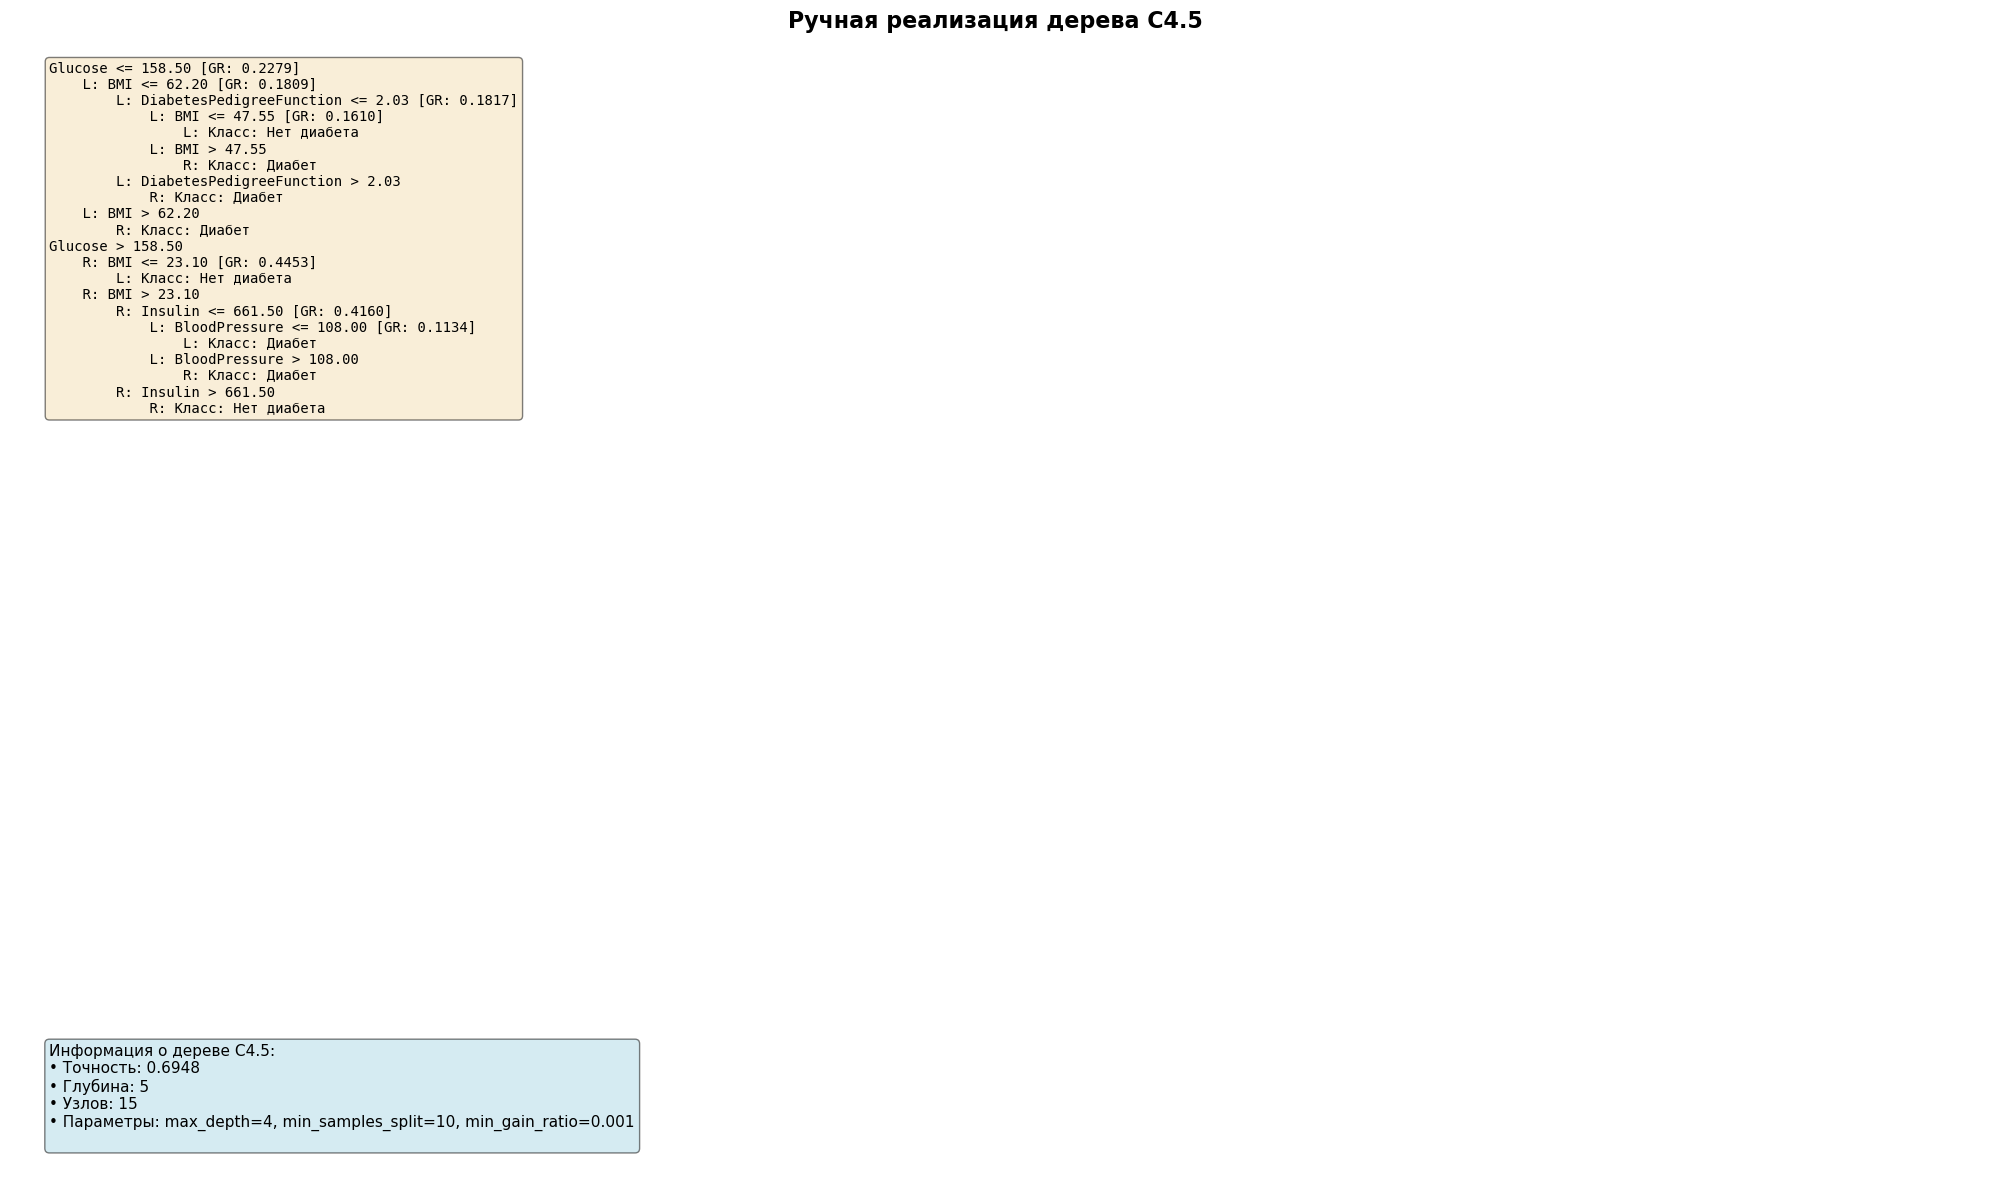


СРАВНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ C4.5 И SCIKIT-LEARN ДЕРЕВЬЕВ


C:\Users\Пользователь\AppData\Local\Temp\ipykernel_2532\1552318775.py:134: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_2532\1552318775.py:134: UserWarning: Glyph 127811 (\N{LEAF FLUTTERING IN WIND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127811 (\N{LEAF FLUTTERING IN WIND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


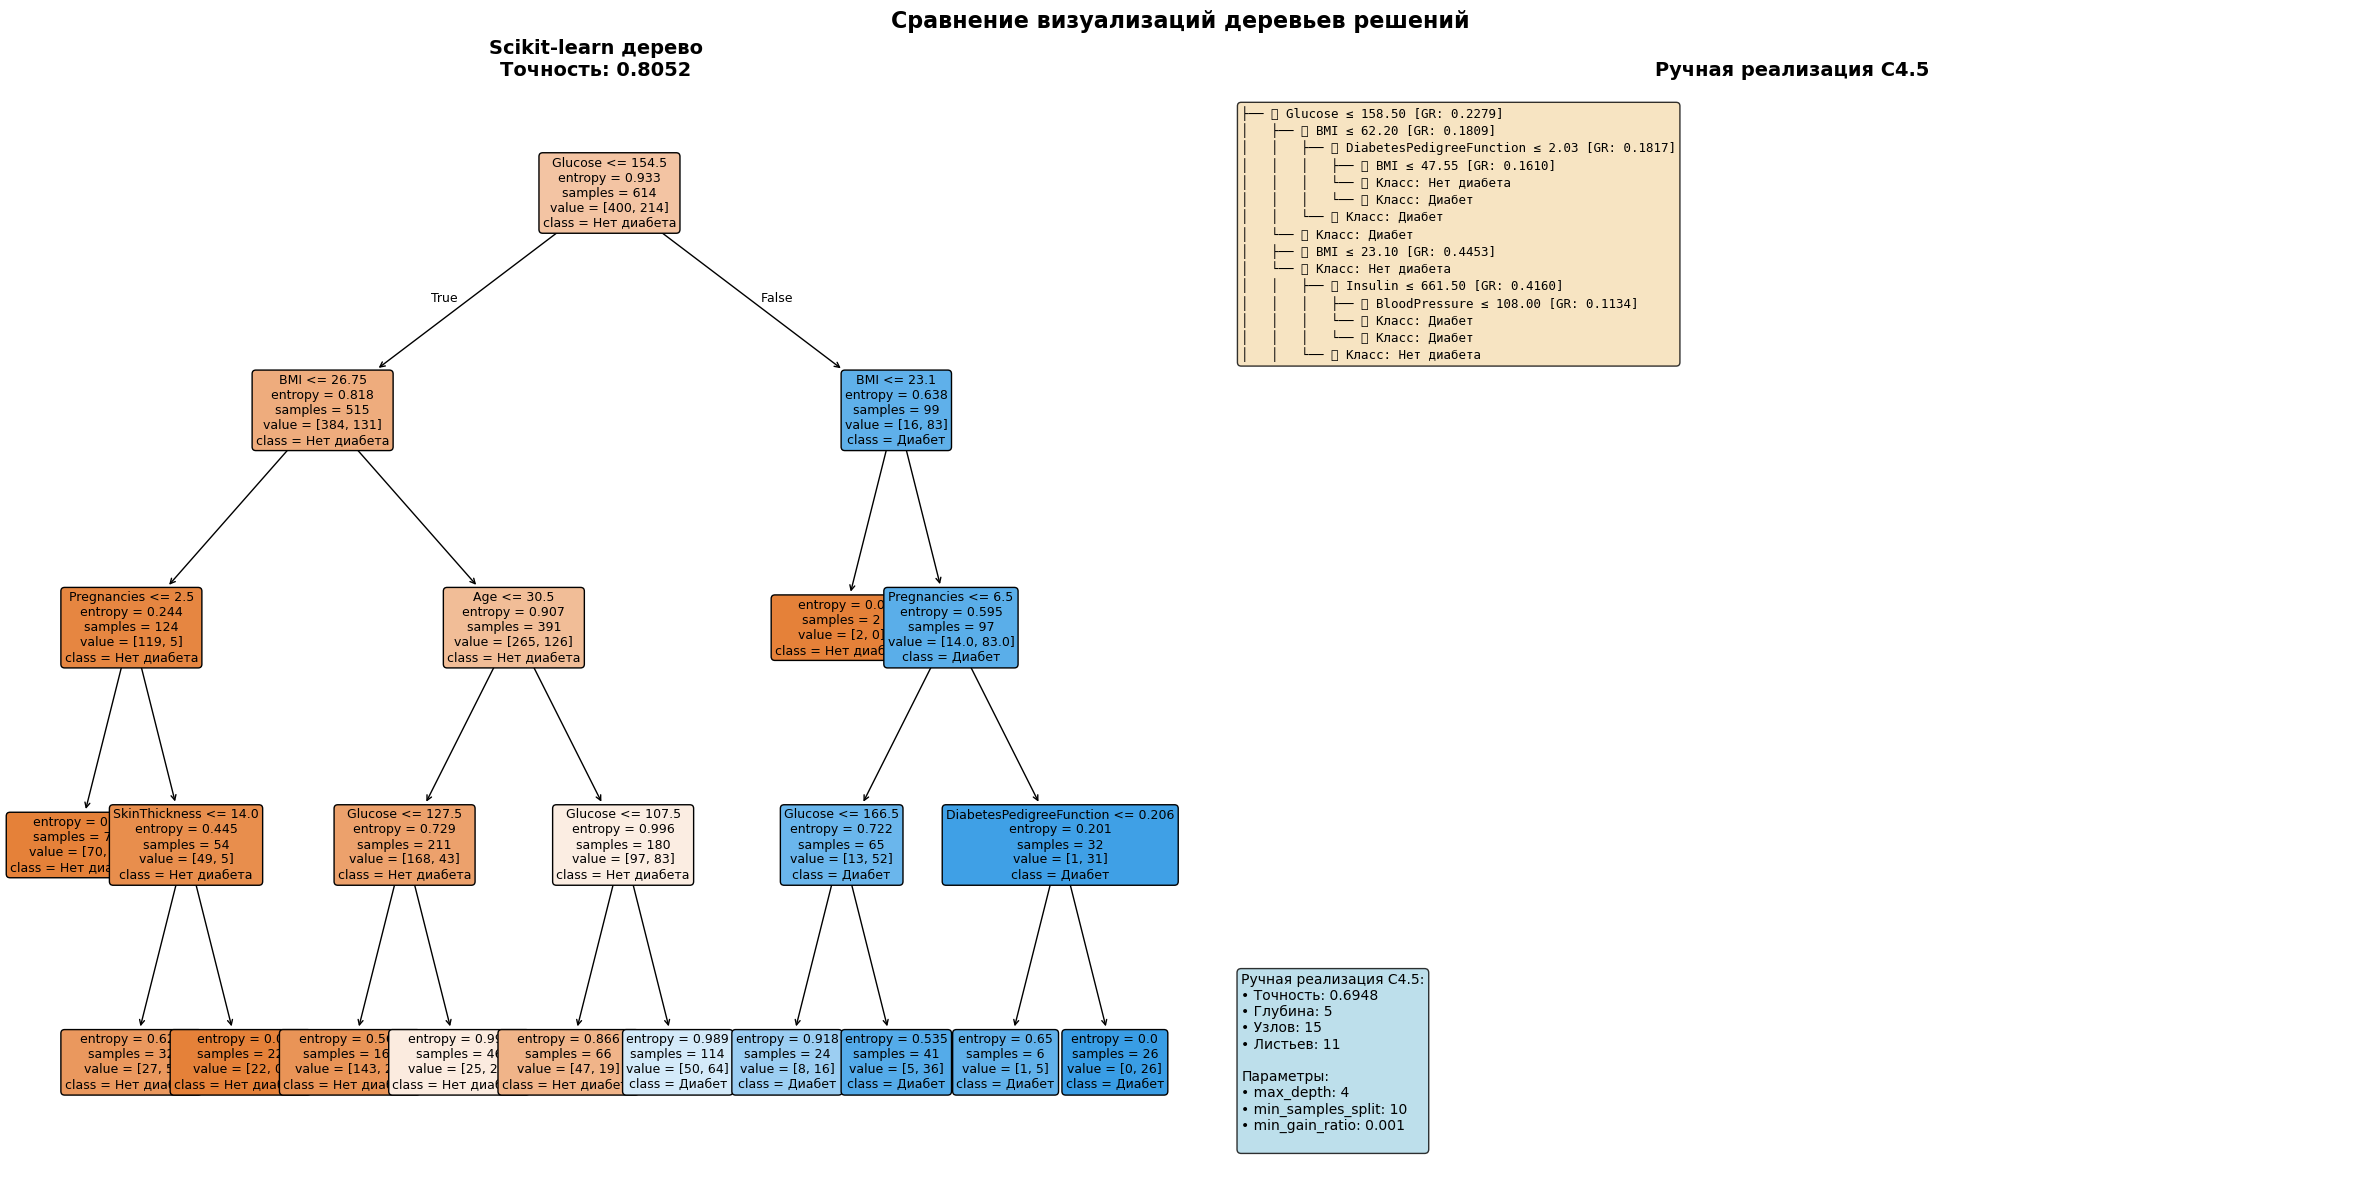


СТАТИСТИКА ПО ДЕРЕВЬЯМ

Статистика                C4.5                 scikit-learn        
-----------------------------------------------------------------
Точность                  0.6948               0.8052              
Всего узлов               15                   23                  
Листовых узлов            8                    12                  
Решающих узлов            7                    11                  
Макс. глубина             4                    4                   

Использование признаков в C4.5 дереве:
  • BMI: 3 раз
  • Glucose: 1 раз
  • DiabetesPedigreeFunction: 1 раз
  • Insulin: 1 раз
  • BloodPressure: 1 раз

АНАЛИЗ РАЗЛИЧИЙ В СТРУКТУРЕ ДЕРЕВЬЕВ


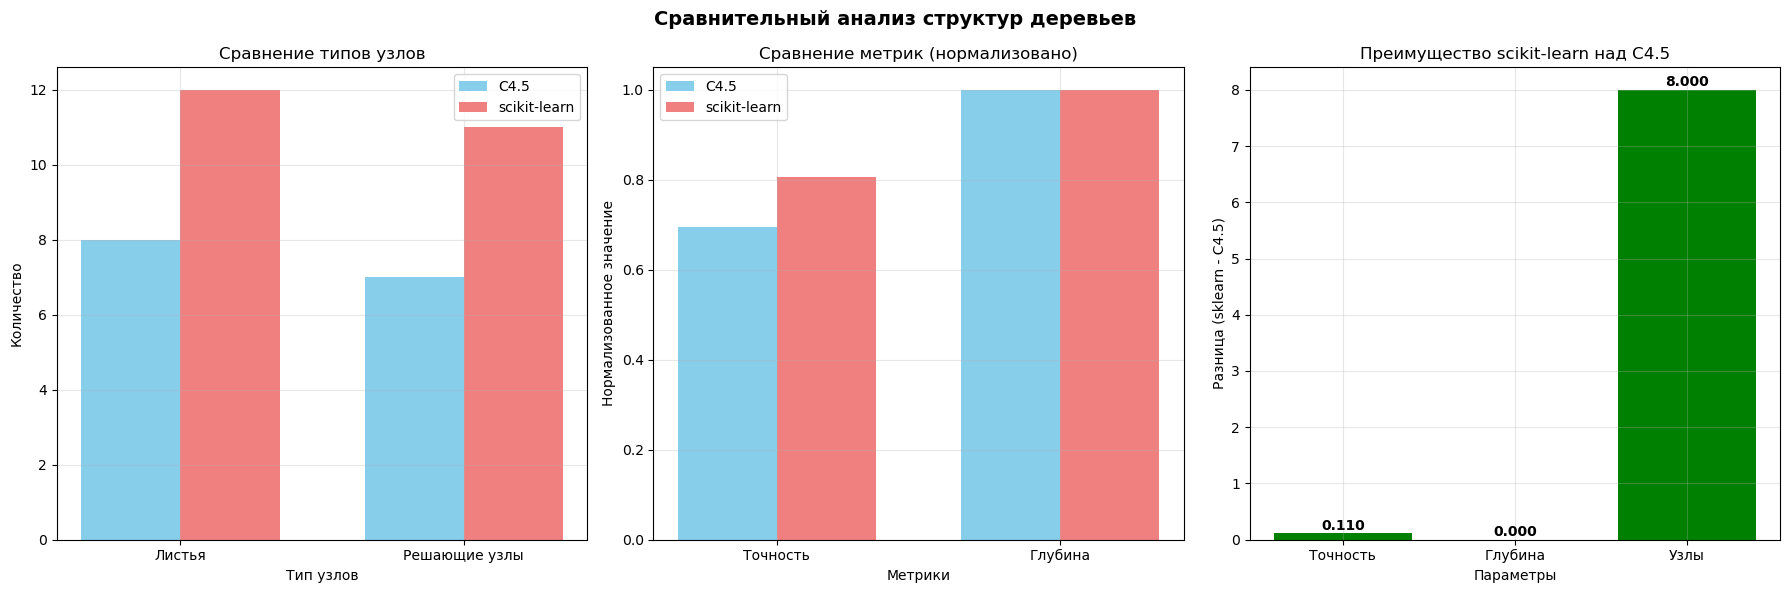


✓ Визуализации успешно созданы!


In [6]:
# ============================================
# ВИЗУАЛИЗАЦИЯ РУЧНОГО ДЕРЕВА C4.5 ЧЕРЕЗ SKLEARN-LIKE ВИЗУАЛИЗАЦИЮ
# ============================================

print("\n" + "="*70)
print("ВИЗУАЛИЗАЦИЯ РУЧНОГО ДЕРЕВА C4.5")
print("="*70)

# Создаем фигуру для визуализации
plt.figure(figsize=(20, 12))

# Для визуализации используем простой подход с отрисовкой текста
# (поскольку мы не можем использовать plot_tree для нашего ручного дерева)

# Создаем подзаголовок
plt.suptitle('Ручная реализация дерева C4.5', fontsize=16, fontweight='bold')

# Текстовое представление дерева с отступами
tree_text = []
def collect_tree_text(node, depth=0, prefix=""):
    if node is None:
        return
    
    indent = "    " * depth
    
    if node.is_leaf:
        class_name = "Диабет" if node.value == 1 else "Нет диабета"
        tree_text.append(f"{indent}{prefix}Класс: {class_name}")
    else:
        feature_name = features[node.feature_index]
        tree_text.append(f"{indent}{prefix}{feature_name} <= {node.threshold:.2f} [GR: {node.gain_ratio:.4f}]")
        collect_tree_text(node.left, depth + 1, "L: ")
        tree_text.append(f"{indent}{prefix}{feature_name} > {node.threshold:.2f}")
        collect_tree_text(node.right, depth + 1, "R: ")

# Собираем текст дерева
collect_tree_text(c45_tree.root)

# Отображаем дерево как текст
ax = plt.gca()
ax.axis('off')  # Выключаем оси

# Добавляем текст дерева
tree_display = "\n".join(tree_text)
ax.text(0.02, 0.98, tree_display, fontfamily='monospace', fontsize=10,
        verticalalignment='top', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Добавляем заголовок и информацию
info_text = f"""Информация о дереве C4.5:
• Точность: {accuracy_c45:.4f}
• Глубина: {c45_tree.get_depth()}
• Узлов: {c45_tree.get_node_count()}
• Параметры: max_depth={MAX_DEPTH}, min_samples_split={MIN_SAMPLES_SPLIT}, min_gain_ratio={MIN_GAIN_RATIO}
"""

ax.text(0.02, 0.02, info_text, fontsize=11,
        verticalalignment='bottom', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

# ============================================
# СРАВНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ ОБОИХ ДЕРЕВЬЕВ
# ============================================

print("\n" + "="*70)
print("СРАВНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ C4.5 И SCIKIT-LEARN ДЕРЕВЬЕВ")
print("="*70)

# Создаем фигуру с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# 1. Визуализация scikit-learn дерева (используем plot_tree)
from sklearn.tree import plot_tree
plot_tree(sklearn_tree, 
          feature_names=features,
          class_names=['Нет диабета', 'Диабет'],
          filled=True,
          rounded=True,
          fontsize=9,
          ax=axes[0])
axes[0].set_title(f'Scikit-learn дерево\nТочность: {accuracy_sklearn:.4f}', 
                  fontsize=14, fontweight='bold')

# 2. Визуализация ручного дерева C4.5 (текстовое представление)
axes[1].axis('off')

# Создаем красивое текстовое представление для C4.5
def format_tree_node(node, depth=0):
    """Форматирует узел дерева для отображения"""
    if node.is_leaf:
        return f"{'│   ' * (depth-1) if depth > 0 else ''}└── 🍃 Класс: {'Диабет' if node.value == 1 else 'Нет диабета'}"
    else:
        feature_name = features[node.feature_index]
        node_text = f"{'│   ' * depth if depth > 0 else ''}├── 📊 {feature_name} ≤ {node.threshold:.2f} [GR: {node.gain_ratio:.4f}]"
        children_text = []
        if node.left:
            children_text.append(format_tree_node(node.left, depth + 1))
        if node.right:
            children_text.append(format_tree_node(node.right, depth + 1))
        return node_text + "\n" + "\n".join(children_text)

# Получаем форматированное дерево
formatted_tree = format_tree_node(c45_tree.root)

# Отображаем дерево C4.5
axes[1].text(0.02, 0.98, formatted_tree, fontfamily='monospace', fontsize=9,
            verticalalignment='top', transform=axes[1].transAxes,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Добавляем информацию о дереве C4.5
c45_info = f"""Ручная реализация C4.5:
• Точность: {accuracy_c45:.4f}
• Глубина: {c45_tree.get_depth()}
• Узлов: {c45_tree.get_node_count()}
• Листьев: {c45_tree.get_node_count() - (c45_tree.get_depth() - 1)}

Параметры:
• max_depth: {MAX_DEPTH}
• min_samples_split: {MIN_SAMPLES_SPLIT}
• min_gain_ratio: {MIN_GAIN_RATIO}
"""

axes[1].text(0.02, 0.02, c45_info, fontsize=10,
            verticalalignment='bottom', transform=axes[1].transAxes,
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

axes[1].set_title('Ручная реализация C4.5', fontsize=14, fontweight='bold')

# Общий заголовок
plt.suptitle('Сравнение визуализаций деревьев решений', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# ВЫВОД СТАТИСТИКИ ПО ДЕРЕВЬЯМ
# ============================================

print("\n" + "="*70)
print("СТАТИСТИКА ПО ДЕРЕВЬЯМ")
print("="*70)

# Собираем статистику по дереву C4.5
def get_tree_stats(tree):
    """Собирает статистику по дереву C4.5"""
    stats = {
        'total_nodes': 0,
        'leaf_nodes': 0,
        'decision_nodes': 0,
        'max_depth': 0,
        'feature_counts': {}
    }
    
    def traverse(node, depth=0):
        if node is None:
            return
        
        stats['total_nodes'] += 1
        stats['max_depth'] = max(stats['max_depth'], depth)
        
        if node.is_leaf:
            stats['leaf_nodes'] += 1
        else:
            stats['decision_nodes'] += 1
            # Считаем использование признаков
            if node.feature_index < len(features):
                feature_name = features[node.feature_index]
                stats['feature_counts'][feature_name] = stats['feature_counts'].get(feature_name, 0) + 1
            
            # Рекурсивно обходим потомков
            if node.left:
                traverse(node.left, depth + 1)
            if node.right:
                traverse(node.right, depth + 1)
    
    traverse(tree.root)
    return stats

# Получаем статистику
c45_stats = get_tree_stats(c45_tree)
sklearn_leaf_count = sklearn_tree.get_n_leaves()

print(f"\n{'Статистика':<25} {'C4.5':<20} {'scikit-learn':<20}")
print("-" * 65)
print(f"{'Точность':<25} {accuracy_c45:<20.4f} {accuracy_sklearn:<20.4f}")
print(f"{'Всего узлов':<25} {c45_stats['total_nodes']:<20} {sklearn_nodes:<20}")
print(f"{'Листовых узлов':<25} {c45_stats['leaf_nodes']:<20} {sklearn_leaf_count:<20}")
print(f"{'Решающих узлов':<25} {c45_stats['decision_nodes']:<20} {sklearn_nodes - sklearn_leaf_count:<20}")
print(f"{'Макс. глубина':<25} {c45_stats['max_depth']:<20} {sklearn_depth:<20}")

print(f"\nИспользование признаков в C4.5 дереве:")
for feature, count in sorted(c45_stats['feature_counts'].items(), key=lambda x: x[1], reverse=True):
    print(f"  • {feature}: {count} раз")

# ============================================
# СРАВНЕНИЕ СТРУКТУР ДЕРЕВЬЕВ
# ============================================

print("\n" + "="*70)
print("АНАЛИЗ РАЗЛИЧИЙ В СТРУКТУРЕ ДЕРЕВЬЕВ")
print("="*70)

# Создаем график сравнения структур
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Сравнение типов узлов
node_types = ['Листья', 'Решающие узлы']
c45_node_counts = [c45_stats['leaf_nodes'], c45_stats['decision_nodes']]
sklearn_node_counts = [sklearn_leaf_count, sklearn_nodes - sklearn_leaf_count]

x = np.arange(len(node_types))
width = 0.35

axes[0].bar(x - width/2, c45_node_counts, width, label='C4.5', color='skyblue')
axes[0].bar(x + width/2, sklearn_node_counts, width, label='scikit-learn', color='lightcoral')
axes[0].set_xlabel('Тип узлов')
axes[0].set_ylabel('Количество')
axes[0].set_title('Сравнение типов узлов')
axes[0].set_xticks(x)
axes[0].set_xticklabels(node_types)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Сравнение точности и глубины
metrics = ['Точность', 'Глубина']
c45_metrics = [accuracy_c45, c45_stats['max_depth']]
sklearn_metrics = [accuracy_sklearn, sklearn_depth]

# Нормализуем для сравнения на одном графике
c45_norm = [val/max(sklearn_metrics[i], 1) for i, val in enumerate(c45_metrics)]
sklearn_norm = [val/max(sklearn_metrics[i], 1) for i, val in enumerate(sklearn_metrics)]

x = np.arange(len(metrics))
axes[1].bar(x - width/2, c45_norm, width, label='C4.5', color='skyblue')
axes[1].bar(x + width/2, sklearn_norm, width, label='scikit-learn', color='lightcoral')
axes[1].set_xlabel('Метрики')
axes[1].set_ylabel('Нормализованное значение')
axes[1].set_title('Сравнение метрик (нормализовано)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Разница в производительности
differences = [
    accuracy_sklearn - accuracy_c45,
    sklearn_depth - c45_stats['max_depth'],
    sklearn_nodes - c45_stats['total_nodes']
]
diff_labels = ['Точность', 'Глубина', 'Узлы']

colors = ['green' if diff >= 0 else 'red' for diff in differences]
axes[2].bar(diff_labels, differences, color=colors)
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_xlabel('Параметры')
axes[2].set_ylabel('Разница (sklearn - C4.5)')
axes[2].set_title('Преимущество scikit-learn над C4.5')
axes[2].grid(True, alpha=0.3)

# Добавляем значения на столбцы
for i, diff in enumerate(differences):
    axes[2].text(i, diff + (0.01 if diff >= 0 else -0.01), 
                f'{diff:.3f}', ha='center', va='bottom' if diff >= 0 else 'top',
                fontweight='bold')

plt.suptitle('Сравнительный анализ структур деревьев', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Визуализации успешно созданы!")